# Assignment 02

Implementasikan histogram of energy, histogram of zero crossing rate, histogram of energy entropy tanpa menggunakan library.

Atha Putra Fausta

24/538657/PA/22864

## Dataset Description

Source:

https://www.kaggle.com/datasets/mathurinache/the-lj-speech-dataset

https://www.youtube.com/watch?v=rEGOihjqO9w

The data being used are speech and music data. The speech data used is a short audio clips of a single speaker reading passages from a non-fiction books, and the music data used is a short clip of Rachmaninoff Piano Concerto no.2 op.18 played by Anna Fedorova.

This notebook will extract histogram of energy, histogram of zero crossing rate, and histogram of energy entropy from the audio data.


## Importing the Data

In [46]:
import wave
import numpy as np

def read_wav(audio):
    wf = wave.open(audio, 'rb')

    fs = wf.getframerate()

    n_frames = wf.getnframes()
    frames = wf.readframes(n_frames)
    signal = np.frombuffer(frames, dtype='int16').astype(float)

    wf.close()
    return signal, fs

In [47]:
speech_signal, speech_fs = read_wav("./data/speech.wav")
music_signal, music_fs = read_wav("./data/rach2.wav")

print(speech_fs)
print(speech_signal[:10])

print(music_fs)
print(music_signal[:10])

22050
[-24. -25. -21. -25. -25. -19. -18. -16. -16. -11.]
48000
[-319. -667. -315. -679. -289. -677. -258. -669. -233. -661.]


## Windowing

Before feature extracting the audio, windowing is implemented with window size of 25ms and overlap of 10ms.

In [48]:
def windowing(signal, fs):
    window_size = int(0.025 * fs)
    overlap   = int(0.010 * fs)

    windows = []

    for i in range(0, len(signal) - window_size, overlap):
        window = signal[i:i + window_size]
        windows.append(window)

    return windows

In [49]:
speech_windows = windowing(speech_signal, speech_fs)
music_windows = windowing(music_signal, music_fs)

print(len(speech_windows))
print(len(music_windows))

966
2319


## Audio Energy

To obtain histogram of audio energy, first audio energy feature is extracted from the audio, then the histogram is constructed from the extracted audio energy. The audio energy feature is calculated with the formula:

$E(i) = \frac{1}{W_L} \sum_{n=1}^{W_L} x_i(n)^2$,

where:
- $E(i)$: energy of the $i$-th frame
- $W_L$: frame length (number of samples per frame)
- $x_i(n)$: the $n$-th sample in frame $i$

In [55]:
def compute_energy(windows):
    energy = []

    for window in windows:
        e = 0
        for x in window:
            e += x * x

        e = e / len(window)
        energy.append(e)

    return energy

In [56]:
# Extracting the audio energy
speech_energy = compute_energy(speech_windows)
music_energy = compute_energy(music_windows)

print(speech_energy[:5])
print(music_energy[:5])

[np.float64(223764.38475499093), np.float64(274740.35571687843), np.float64(291904.8784029038), np.float64(41574.10889292196), np.float64(7636937.295825771)]
[np.float64(67967.85666666667), np.float64(90234.1975), np.float64(100394.2375), np.float64(67888.2525), np.float64(51133.378333333334)]


In [91]:
# Histogram of audio energy
def construct_histogram(data, bin_edges):
    hist = [0] * (len(bin_edges) - 1)

    for x in data:
        for i in range(len(bin_edges) - 1):
            if bin_edges[i] <= x < bin_edges[i+1]:
                hist[i] += 1
                break

    total = sum(hist)
    hist = [h / total for h in hist]

    return hist

In [99]:
_, bin_edges = np.histogram(music_energy + speech_energy, bins=256)

hist_music = construct_histogram(music_energy, bin_edges)
hist_speech = construct_histogram(speech_energy, bin_edges)

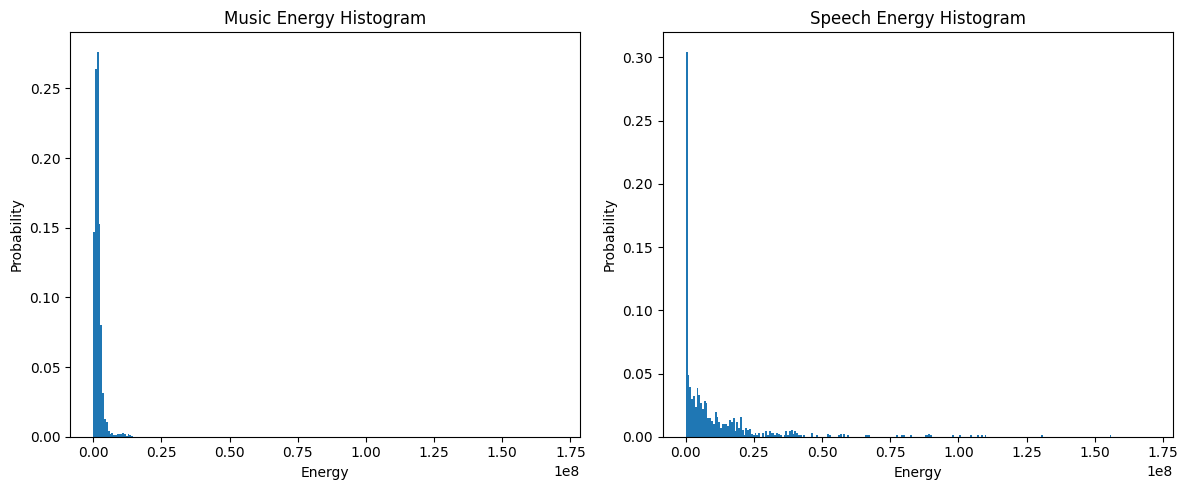

In [100]:
import matplotlib.pyplot as plt

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
width = bin_edges[1] - bin_edges[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(bin_centers, hist_music, width=width)
plt.title("Music Energy Histogram")
plt.xlabel("Energy")
plt.ylabel("Probability")

plt.subplot(1, 2, 2)
plt.bar(bin_centers, hist_speech, width=width)
plt.title("Speech Energy Histogram")
plt.xlabel("Energy")
plt.ylabel("Probability")

plt.tight_layout()
plt.show()

From the diagram above, both music and speech energy histogram are skewed to the left. That means both audio has few frames with high energy. However speech energy histogram showed higher variability in energy, caused by variability in speech, such as silence, unvoiced sounds, and voiced sounds (vowels).

## Zero Crossing Rate

To obtain histogram of zero crossing rate (ZCR), first zcr feature is extracted from the audio, then the histogram is constructed from the extracted ZCR. The ZCR feature is calculated with the formula:

$
Z(i) = \frac{1}{2W_L} \sum_{n=1}^{W_L} \left| \operatorname{sgn}(x_i(n)) - \operatorname{sgn}(x_i(n-1)) \right|
$

where:
- $Z(i)$: Zero Crossing Rate of the $i$-th frame
- $W_L$: frame length (number of samples in the frame)
- $x_i(n)$: the $n$-th sample of frame $i$
- $\operatorname{sgn}(x)$: sign function defined as:

$
\operatorname{sgn}(x) =
\begin{cases}
1, & x \ge 0 \\
-1, & x < 0
\end{cases}
$

Audio with high ZCR means noisy signals or unvoiced speech and audio with low ZCR means smooth signals such as music or voiced speech.

In [101]:
# Calculating ZCR
def compute_zcr_window(window):
    count = 0

    for i in range(1, len(window)):
        if (window[i] >= 0 and window[i-1] < 0) or (window[i] < 0 and window[i-1] >= 0):
            count += 1

    zcr = count / len(window)
    return zcr

def compute_zcr(windows):
    zcr_values = []

    for window in windows:
        z = compute_zcr_window(window)
        zcr_values.append(z)

    return zcr_values

In [102]:
zcr_music = compute_zcr(music_windows)
zcr_speech = compute_zcr(speech_windows)

print(zcr_music[:5])
print(zcr_speech[:5])

[0.3491666666666667, 0.35833333333333334, 0.5383333333333333, 0.5825, 0.5516666666666666]
[0.13430127041742287, 0.19419237749546278, 0.22686025408348456, 0.24682395644283123, 0.14519056261343014]


In [103]:
# Construct ZCR Histogram
_, bin_edges = np.histogram(zcr_music + zcr_speech, bins=256)

hist_zcr_music = construct_histogram(zcr_music, bin_edges)
hist_zcr_speech = construct_histogram(zcr_speech, bin_edges)

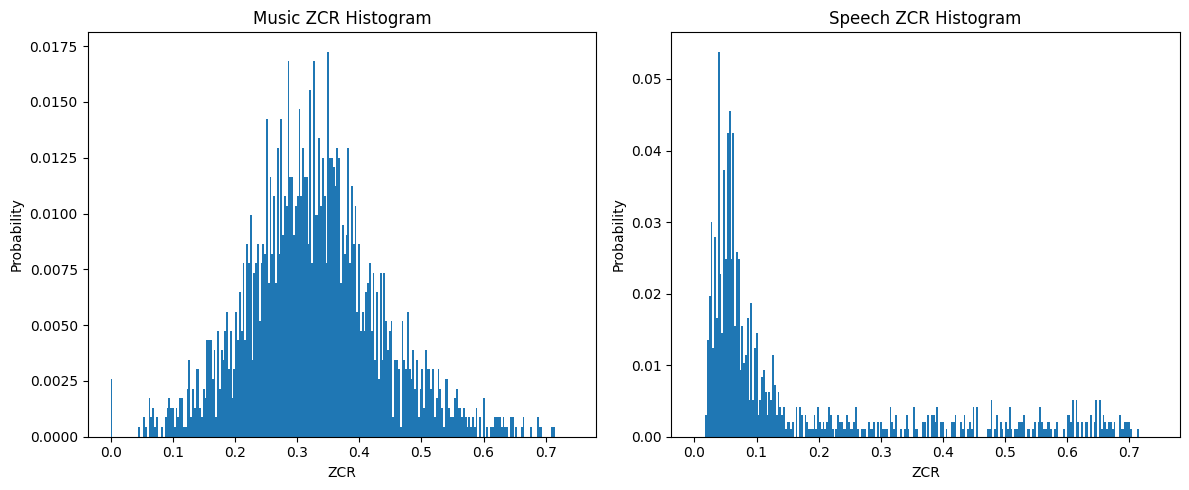

In [104]:
import matplotlib.pyplot as plt

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
width = bin_edges[1] - bin_edges[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(bin_centers, hist_zcr_music, width=width)
plt.title("Music ZCR Histogram")
plt.xlabel("ZCR")
plt.ylabel("Probability")

plt.subplot(1, 2, 2)
plt.bar(bin_centers, hist_zcr_speech, width=width)
plt.title("Speech ZCR Histogram")
plt.xlabel("ZCR")
plt.ylabel("Probability")

plt.tight_layout()
plt.show()

Above, the music ZCR shows a relatively symmetric shaped histogram, while the speech ZCR histogram is skewed to the left. Music has high variation of signal type, such as harmonic components with low ZCR and percussion with high ZCR. On the other hand, speech audio are mostly consist of voiced sounds, which are smooth, meaning low ZCR.

## Audio Entropy

To obtain histogram of audio entropy, first audio entropy feature is extracted from the audio, then the histogram is constructed from the extracted audio entropy. The audio entropy feature is calculated with the formula:

The normalized energy of subframe $j$ is defined as:

$
e_j = \frac{E_{\text{subframe}_j}}{E_{\text{shortframe}_i}}
$

where the total energy of frame $i$ is:

$
E_{\text{shortframe}_i} = \sum_{k=1}^{K} E_{\text{subframe}_k}
$

The energy entropy of frame $i$ is then:

$
H(i) = - \sum_{j=1}^{K} e_j \cdot \log_2(e_j)
$

Audio with high entropy means that energy is evenly distributed across subframes, and audio with low entropy means that energy is concentrated in a few subframes.

In [109]:
# Calculate energy entropy
import math

def compute_entropy_frame(frame, num_subframes=10):
    frame_length = len(frame)
    subframe_length = frame_length // num_subframes

    total_energy = 0.0
    for x in frame:
        total_energy += x * x

    if total_energy == 0:
        return 0

    entropy = 0.0

    for i in range(num_subframes):
        start = i * subframe_length
        end = start + subframe_length
        subframe = frame[start:end]

        sub_energy = 0.0
        for x in subframe:
            sub_energy += x * x

        e_j = sub_energy / total_energy

        if e_j > 0:
            entropy -= e_j * math.log2(e_j)

    return entropy

In [110]:
def compute_entropy(frames, num_subframes=10):
    entropy_values = []

    for frame in frames:
        h = compute_entropy_frame(frame, num_subframes)
        entropy_values.append(h)

    return entropy_values

In [112]:
entropy_music = compute_entropy(music_windows)
entropy_speech = compute_entropy(speech_windows)

print(entropy_music[:5])
print(entropy_speech[:5])

[np.float64(3.20626735130455), np.float64(3.1237039346228337), np.float64(3.1533397391390974), np.float64(3.1427403127285496), np.float64(3.130079603315356)]
[np.float64(0.8256543193991585), np.float64(1.6228708700649181), np.float64(1.9586457147575367), np.float64(3.1536284684536735), np.float64(1.2246046898759646)]


In [116]:
# Construct audio entropy histogram
_, bin_edges = np.histogram(entropy_music + entropy_speech, bins=256)

hist_entropy_music = construct_histogram(entropy_music, bin_edges)
hist_entropy_speech = construct_histogram(entropy_speech, bin_edges)

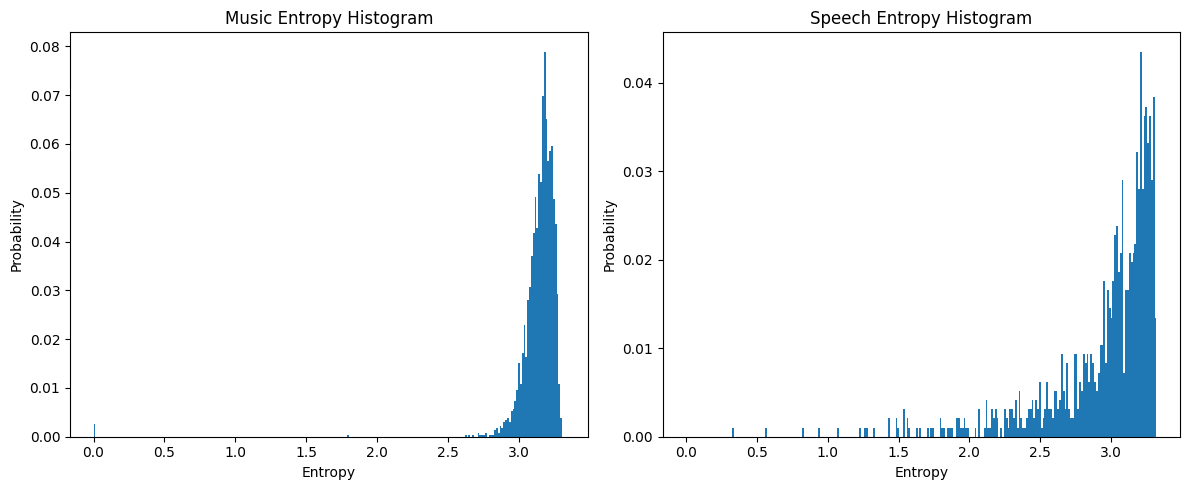

In [117]:
import matplotlib.pyplot as plt

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
width = bin_edges[1] - bin_edges[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(bin_centers, hist_entropy_music, width=width)
plt.title("Music Entropy Histogram")
plt.xlabel("Entropy")
plt.ylabel("Probability")

plt.subplot(1, 2, 2)
plt.bar(bin_centers, hist_entropy_speech, width=width)
plt.title("Speech Entropy Histogram")
plt.xlabel("Entropy")
plt.ylabel("Probability")

plt.tight_layout()
plt.show()

Both music and speech entropy histogram are skewed to the right. However, there is slightly more variance in speech entropy. This means that both music and speech has high complexity, but the speech audio has less consistent switching between structured and noisy segment.

## References

https://rizdelhi.medium.com/read-audio-data-in-python-5b761312b4b3